# Reconocimiento Dígitos DB MINST con CNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Importación de los datos

In [2]:
from keras.datasets import mnist  #fashion_mnist para la tarea

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#### Exploracion de los datos

In [4]:
print(X_train[0].shape)

(28, 28)


In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [ ]:
#X_train

In [5]:
y_train[0]

np.uint8(5)

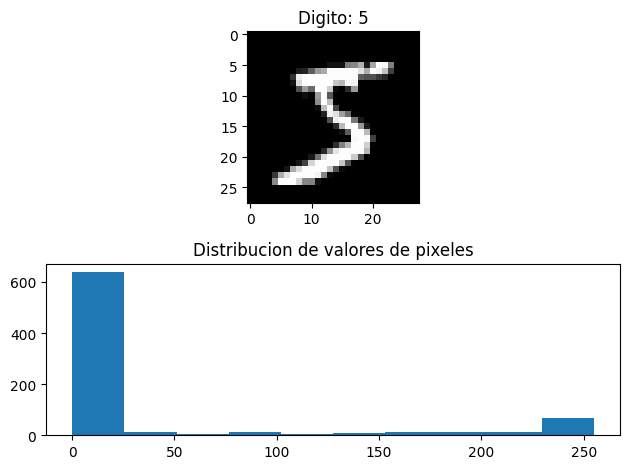

In [7]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.imshow(X_train[0], cmap='gray', interpolation='none')
plt.title("Digito: {}".format(y_train[0]))
plt.subplot(2,1,2)
plt.hist(X_train[0].reshape(784))
plt.title("Distribucion de valores de pixeles")
plt.tight_layout()
plt.show()

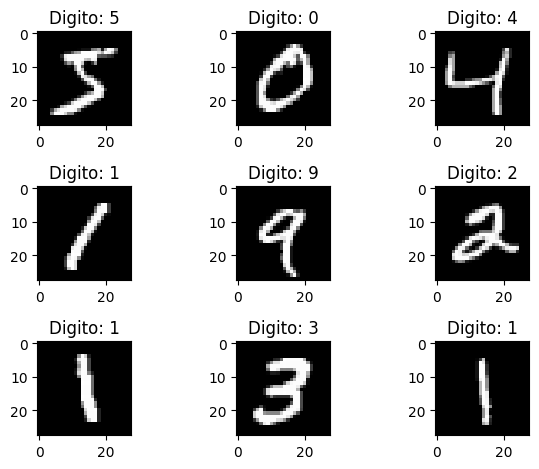

In [8]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(X_train[i], cmap='gray', interpolation='none')
    plt.title("Digito: {}".format(y_train[i]))

#### Preprocesamiento

Primero escalamos los datos, como los valores van de 0 a 255, basta solamente con dividir por 255

In [9]:
X_train=X_train/255
X_test=X_test/255

Ahora, lo llevaremos de un shape (60000, 28, 28) lo transformaremos en un shape (60000, 28, 28, 1). Esto, porque así lo requiere keras:

In [10]:
X_train=X_train.reshape((60000,28,28,1))
X_test=X_test.reshape((10000,28,28,1))

In [ ]:
#X_train

#### Seguimos con la transformación de la respuesta, se debe llevar a un vector

#### Diseño de la Arquitectura de la Red

- Input vector: (28,28,1)

- Layer Conv2D: 32 capas con kernel de 3x3 con activacion relu
- Layer MaxPooling: con size de 2x2

- Layer Conv2D: 64 capas con kernel de 3x3 con activacion relu
- Layer MaxPooling: con size de 2x2

- Layer aplanamiento
- Layer Dropout de 0.5
- Layer Denso: con 10 categorías y activacion softmax

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

In [14]:
model = Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy'])

In [ ]:
model.summary()

In [16]:
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,10)

In [17]:
y_test=to_categorical(y_test,10)

#### Entrenamiento del Modelo

In [18]:
model.fit(X_train,y_train,epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9488 - loss: 0.1645
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9715 - loss: 0.0965
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9735 - loss: 0.0899
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9747 - loss: 0.0844
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 47ms/step - accuracy: 0.9751 - loss: 0.0858


#### Métricas de Evaluación

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred

array([[7.51616547e-09, 1.22629484e-09, 6.32215858e-07, ...,
        9.99932706e-01, 3.72752718e-09, 6.58986610e-05],
       [7.90613121e-05, 2.77905019e-05, 9.99884427e-01, ...,
        5.62720252e-11, 2.05223486e-07, 6.16727294e-11],
       [1.05985322e-07, 9.99855042e-01, 7.48357979e-06, ...,
        3.50559931e-05, 9.37177174e-06, 1.14773336e-07],
       ...,
       [9.60260341e-17, 2.30884686e-11, 2.44180923e-13, ...,
        1.46057555e-10, 1.88878282e-08, 9.28335020e-10],
       [1.10100711e-06, 2.27734932e-11, 5.35225406e-11, ...,
        3.11178201e-11, 8.18121422e-04, 1.34080040e-06],
       [2.61955915e-06, 8.32732147e-12, 1.36818770e-08, ...,
        3.56160719e-14, 4.51654181e-08, 1.92879324e-10]], dtype=float32)

In [ ]:
y_pred_label=np.argmax(y_pred,axis=1)

In [ ]:
y_pred_label

array([7, 2, 1, ..., 4, 5, 6])

In [ ]:
y_test=np.argmax(y_test,axis=1)

In [ ]:
y_test

array([7, 2, 1, ..., 4, 5, 6])

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


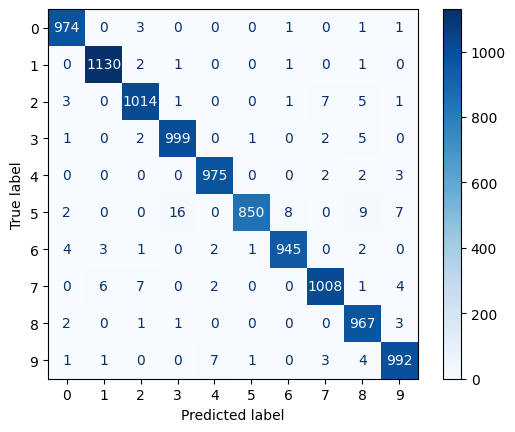

In [ ]:
# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_label)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_label))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.97      0.99      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.97      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

